In [2]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from lifetimes import BetaGeoFitter
from datetime import timedelta
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from memory_profiler import memory_usage
import pickle
import os
import time
import shap

In [3]:
# ============================================
# 1. CARGAR DATOS DE CLIENTES
# ============================================
# Cargar dataset con métricas de CLV
df = pd.read_csv("./data/customer_clv.csv")

print("\n=== DATASET CARGADO ===\n")
print(f"Dimensiones: {df.shape[0]:,} clientes x {df.shape[1]} variables")
print("\nMuestras aleatorias:")
print(df.sample(5))


=== DATASET CARGADO ===

Dimensiones: 694,608 clientes x 26 variables

Muestras aleatorias:
          user_id  monetary  avg_ticket  frequency  total_views  total_carts  \
413371  548372063    437.10      437.10          1            6            2   
500803  558072607    164.46      164.46          1            2            1   
395833  546338063     70.01       70.01          1           17            0   
297275  532067689   1096.53     1096.53          1            3            1   
86689   514533428    500.03      500.03          1            3            0   

        avg_time_view  avg_time_cart       first_purchase  \
413371      17.185833       0.049444  2019-11-03 07:46:18   
500803       0.045556       0.035278  2019-11-17 14:04:40   
395833     144.507222            NaN  2019-11-02 19:12:04   
297275       9.256944       0.007500  2019-10-27 06:06:38   
86689        0.101389            NaN  2019-10-28 10:26:13   

              last_purchase  ...  views_per_purchase  carts

In [4]:
# ============================================
# 2. LIMPIEZA DE OUTLIERS
# ============================================
# Eliminar outliers extremos para estabilidad del modelo
# Mantener percentil 5% - 95% para análisis robustos
customer_df_clean = df.copy()
customer_df_clean = customer_df_clean[customer_df_clean["CLV"] <= customer_df_clean["CLV"].quantile(0.95)]
customer_df_clean = customer_df_clean[customer_df_clean["CLV"] >= customer_df_clean["CLV"].quantile(0.05)]


print(f"Datos tras limpieza: {customer_df_clean.shape[0]:,} clientes")

Datos tras limpieza: 627,307 clientes


Selección de características para el modelo

In [5]:
# ============================================
# 3. SELECCIÓN DE CARACTERÍSTICAS
# ============================================
# Variables predictoras relevantes para modelo de CLV
features = [
    "recency",
    "total_views",
    "total_carts",
    "conversion_rate",
    "cart_rate",
    "views_per_purchase",
    "carts_per_purchase",
    "avg_time_between_purchases"
]

# Matriz de características y variable objetivo
X = customer_df_clean[features].fillna(0)
y = customer_df_clean["CLV"]

Estandarización de variables

In [6]:
# ============================================
# 4. ESTANDARIZACIÓN DE CARACTERÍSTICAS
# ============================================
# Escalar variables para normalizar rangos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Modelado de CLV con Random Forest (versión limpia)

División de datos Train/Test

In [7]:
# ============================================
# 5. DIVISIÓN DE DATOS
# ============================================
# Separar datos en entrenamiento y prueba (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=123
)

Entrenamiento del modelo

In [8]:
# ============================================
# 6. ENTRENAMIENTO DEL MODELO
# ============================================
# Modelo de Random Forest con 50 árboles

start_fit = time.perf_counter()

model = RandomForestRegressor(
    n_estimators=50,
    random_state=123
)

model.fit(X_train, y_train)

fit_time = time.perf_counter() - start_fit

Evaluación del modelo

In [9]:
# ============================================
# 7. EVALUACIÓN DEL DESEMPEÑO
# ============================================
# Realizar predicciones en datos de prueba
start_pred = time.perf_counter()

y_pred = model.predict(X_test)

predict_time = time.perf_counter() - start_pred
latency_ms = (predict_time / len(X_test)) * 1000
throughput = len(X_test) / predict_time

# Calcular métricas de error
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
corr, _ = pearsonr(y_test, y_pred)
spearman = spearmanr(y_test, y_pred).correlation

print("\n=== MÉTRICAS DEL RANDOM FOREST ===\n")

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")
print(f"Pearson corr: {corr:.3f}")
print(f"Spearman corr: {spearman:.3f}")
print(f"Tiempo de entrenamiento: {fit_time:.2f} segundos")
print(f"Tiempo de predicción: {predict_time:.2f} segundos")
print(f"Latencia por predicción: {latency_ms:.2f} ms")
print(f"Throughput: {throughput:.2f} predicciones/segundo")


=== MÉTRICAS DEL RANDOM FOREST ===

MAE: 300.86
MAPE: 152.91%
RMSE: 429.59
R2: 0.199
Pearson corr: 0.473
Spearman corr: 0.439
Tiempo de entrenamiento: 54.48 segundos
Tiempo de predicción: 1.92 segundos
Latencia por predicción: 0.02 ms
Throughput: 65252.46 predicciones/segundo


In [10]:
segments = ["Low", "Mid-Low", "Mid-High", "High"]

y_test_df = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred,
    "monetary_segment": pd.qcut(y_test, 4, labels=segments)
})
def metrics(group):
    return pd.Series({
        "MAE": mean_absolute_error(group["y_test"], group["y_pred"]),
        "RMSE": np.sqrt(mean_squared_error(group["y_test"], group["y_pred"])),
        "R2": group[["y_test", "y_pred"]].corr().iloc[0, 1],
        "Spearman": group["y_test"].corr(group["y_pred"], method="spearman"),
        "Pearson": group["y_test"].corr(group["y_pred"], method="pearson")
    })
segment_metrics_rf = y_test_df.groupby("monetary_segment").apply(
    metrics,
    include_groups=False
)

print("\n=== MÉTRICAS DEL RANDOM FOREST por segmento monetary ===\n")
print(segment_metrics_rf)


=== MÉTRICAS DEL RANDOM FOREST por segmento monetary ===

                         MAE        RMSE        R2  Spearman   Pearson
monetary_segment                                                      
Low               245.691693  289.709272  0.145675  0.156569  0.145675
Mid-Low           183.514242  263.888542  0.066666  0.039620  0.066666
Mid-High          198.013778  288.190917  0.142396  0.143792  0.142396
High              576.187815  708.211629  0.278440  0.233797  0.278440


In [11]:
# ============================================
# 8. ANÁLISIS DESCRIPTIVO DEL CLV 
# ============================================
print("\n=== ESTADÍSTICAS DE CLV ===\n")
print(y.describe())


=== ESTADÍSTICAS DE CLV ===

count    627307.000000
mean        446.073294
std         480.742418
min          30.760000
25%         127.910000
50%         254.840000
75%         578.635000
max        2467.820000
Name: CLV, dtype: float64


 - MAE ~= 300, sobre un CLV medio de 525, implica un error relativo aproximado del 57%.
 - RMSE ~= 428, lo que indica una reducción importante de los errores grandes respecto a iteraciones anteriores del modelo.

El modelo funciona ligeramente mejor para el caso medio (71% vs 72%), sin embargo se ve una notable mejora en el RMSE(428 vs 1462). Esto nos indica que reducir los outliers ha mejorado los de fallo extremo de las predicciones, presentado tambien una ligera mejora en la funcionalidad del modelo.


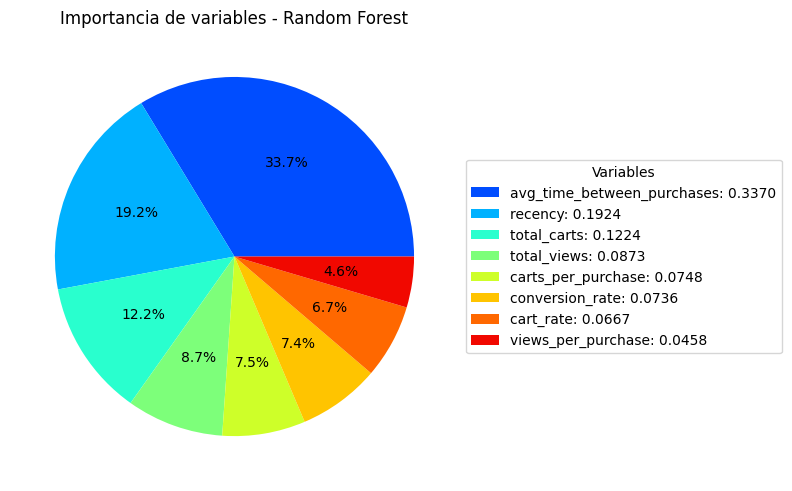


=== IMPORTANCIA DE VARIABLES RANDOM FOREST ===

avg_time_between_purchases    0.336952
recency                       0.192424
total_carts                   0.122432
total_views                   0.087302
carts_per_purchase            0.074812
conversion_rate               0.073570
cart_rate                     0.066734
views_per_purchase            0.045774
dtype: float64


In [12]:
# ============================================
# 9. IMPORTANCIA DE CARACTERÍSTICAS RANDOM FOREST 
# ============================================
# Ordenar características por importancia
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Esquema de colores para las variables
cmap = plt.cm.jet
colors = cmap(np.linspace(0.2, 0.9, len(importance)))

feature_color = {
    feat: color
    for feat, color in zip(importance.index, colors)
}


plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    importance.values,
    labels=None,  
    colors=[feature_color[f] for f in importance.index],
    autopct="%1.1f%%"
)

legend_labels = [
    f"{feat}: {val:.4f}"
    for feat, val in zip(importance.index, importance.values)
]

plt.legend(
    wedges,
    legend_labels,
    title="Variables",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()

print("\n=== IMPORTANCIA DE VARIABLES RANDOM FOREST ===\n")
print(importance)

Antes dominaba:
 - total_views (~0.56), comportamiento muy sesgado hacia actividad

Ahora:
 - avg_time_between_purchases (0.337)
 - recency (0.192)
 - total_carts (0.121)
 - total_views (0.087)

Las variables temporales pasan a ser dominantes
 - avg_time_between_purchases, frecuencia real del cliente
 - recency, cuánto tiempo ha pasado desde la última compra

Esto es coherente con teoría de CLV clientes que compran frecuentemente y recientemente generan mayor valor.

Se observa un menor peso de views. Esto indica que el modelo ahora capta mejor intención de compra real, no solo interacción.

total_carts gana peso siendo este un mejor proxy de intención que views.

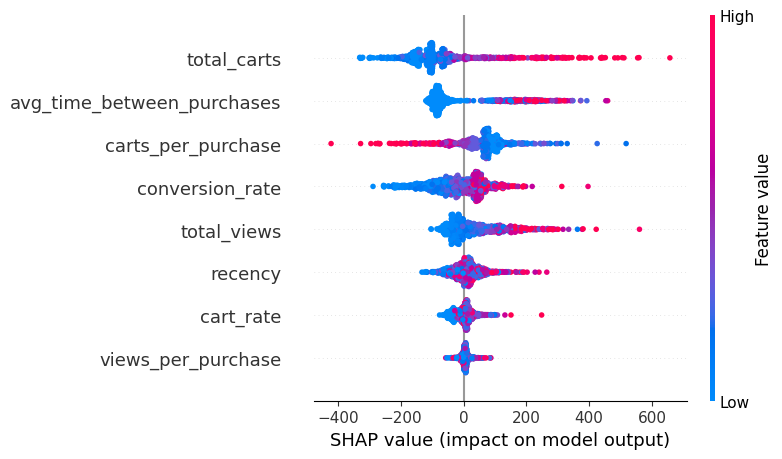

In [13]:
# crear explainer
explainer = shap.TreeExplainer(
    model,
    approximate=True
)


# calcular shap values
X_shap = X_test[:1000]
shap_values = explainer.shap_values(X_shap)

# ============================================
# SUMMARY PLOT
# ============================================

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns
)

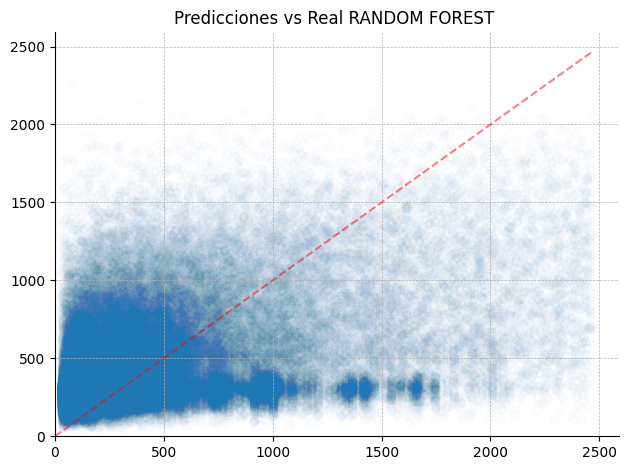

In [14]:
# Encontrar el valor máximo para establecer límites
max_valor_real = max(y_test.max(), y_test.max())
max_valor_pred = max(y_pred.max(), y_pred.max())
limite_max = max(max_valor_real, max_valor_pred)

plt.title("Predicciones vs Real RANDOM FOREST ")
plt.scatter(y_test, y_pred, alpha=0.01)
plt.plot([0, limite_max], [0, limite_max], 'r--', alpha=0.5)  # Línea de referencia

plt.tight_layout()

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

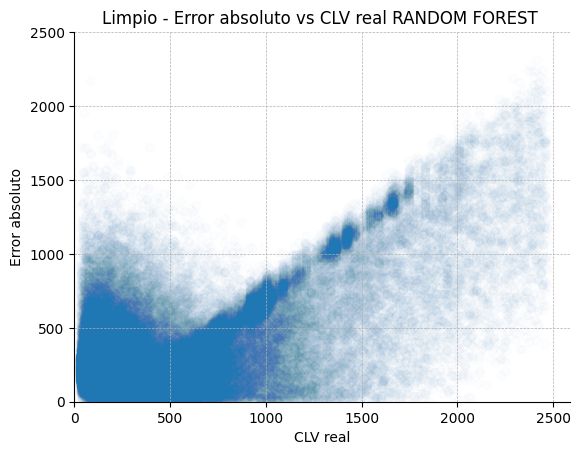

In [15]:
abs_errors = abs( y_test - y_pred)

plt.figure()
plt.scatter(y_test, abs_errors, alpha=0.01)
plt.title("Limpio - Error absoluto vs CLV real RANDOM FOREST ")
plt.xlabel("CLV real")
plt.ylabel("Error absoluto")

plt.xlim(0)
plt.ylim(0,2500)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

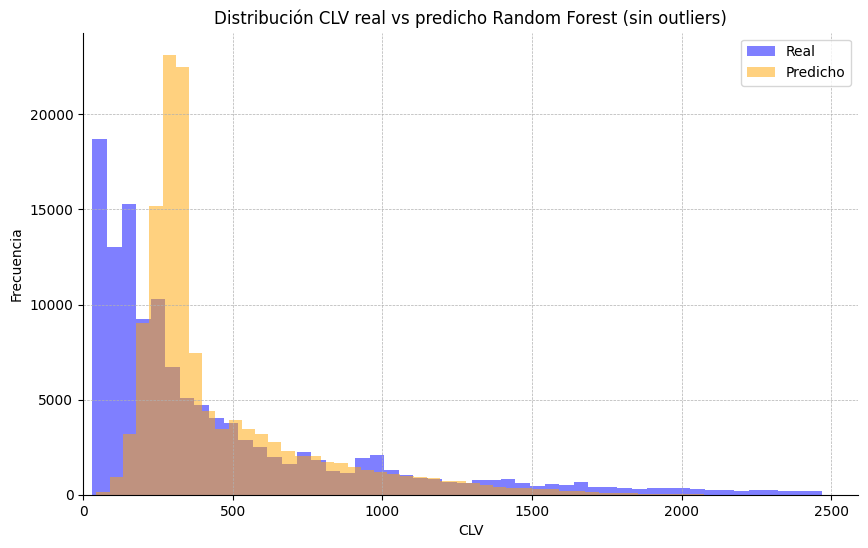

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(y_test, bins=50, alpha=0.5, label="Real", color='blue')
plt.hist(y_pred, bins=50, alpha=0.5, label="Predicho", color='orange')
plt.title("Distribución CLV real vs predicho Random Forest (sin outliers)")
plt.xlabel("CLV")
plt.ylabel("Frecuencia")
plt.legend()
plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

El nuevo modelo es claramente superior en términos prácticos, es más preciso (menor MAE y RMSE) y robusto (menos afectado por outliers).

In [17]:
# Guardar modelo entrenado en un archivo pickle
with open('RF_model.pkl','wb') as f:
    pickle.dump(model,f)

## Modelado de CLV con XGBOOST(versión limpia)

In [18]:
# ============================================
# 6. ENTRENAMIENTO DEL MODELO XGBOOST
# ============================================

from xgboost import XGBRegressor

start_fit = time.perf_counter()

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=15,
    gamma=0.2,
    reg_alpha=1,
    reg_lambda=3,
    random_state=123
)


xgb_model.fit(X_train, y_train)

fit_time = time.perf_counter() - start_fit

In [19]:
# ============================================
# 7. EVALUACIÓN DEL XGBOOST
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Predicciones
start_pred = time.perf_counter()

y_pred_xgb = xgb_model.predict(X_test)

predict_time = time.perf_counter() - start_pred
latency_ms = (predict_time / len(X_test)) * 1000
throughput = len(X_test) / predict_time

# Métricas
mae = mean_absolute_error(y_test, y_pred_xgb)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)
corr, _ = pearsonr(y_test, y_pred_xgb)
spearman = spearmanr(y_test, y_pred_xgb).correlation

print("\n=== MÉTRICAS DEL XGBOOST ===\n")

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")
print(f"Pearson corr: {corr:.3f}")
print(f"Spearman corr: {spearman:.3f}")
print(f"Tiempo de entrenamiento: {fit_time:.2f} segundos")
print(f"Tiempo de predicción: {predict_time:.2f} segundos")
print(f"Latencia por predicción: {latency_ms:.2f} ms")
print(f"Throughput: {throughput:.2f} predicciones/segundo")



=== MÉTRICAS DEL XGBOOST ===

MAE: 285.76
MAPE: 152.91%
RMSE: 404.31
R2: 0.291
Pearson corr: 0.539
Spearman corr: 0.496
Tiempo de entrenamiento: 6.62 segundos
Tiempo de predicción: 0.23 segundos
Latencia por predicción: 0.00 ms
Throughput: 556093.60 predicciones/segundo


In [20]:

y_test_df = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred_xgb,
    "monetary_segment": pd.qcut(y_test, 4, labels=segments)
})
def metrics(group):
    return pd.Series({
        "MAE": mean_absolute_error(group["y_test"], group["y_pred"]),
        "RMSE": np.sqrt(mean_squared_error(group["y_test"], group["y_pred"])),
        "R2": group[["y_test", "y_pred"]].corr().iloc[0, 1],
        "Spearman": group["y_test"].corr(group["y_pred"], method="spearman"),
        "Pearson": group["y_test"].corr(group["y_pred"], method="pearson")
    })
segment_metrics_xgb = y_test_df.groupby("monetary_segment").apply(
    metrics,
    include_groups=False
)

print("\n=== MÉTRICAS DEL XGBOOST por segmento monetary ===\n")
print(segment_metrics_xgb)


=== MÉTRICAS DEL XGBOOST por segmento monetary ===

                         MAE        RMSE        R2  Spearman   Pearson
monetary_segment                                                      
Low               244.627008  270.460816  0.195003  0.203071  0.195003
Mid-Low           175.927374  229.704304  0.081351  0.043607  0.081351
Mid-High          168.792248  230.704009  0.179053  0.173907  0.179053
High              553.640731  688.986543  0.319651  0.259343  0.319651


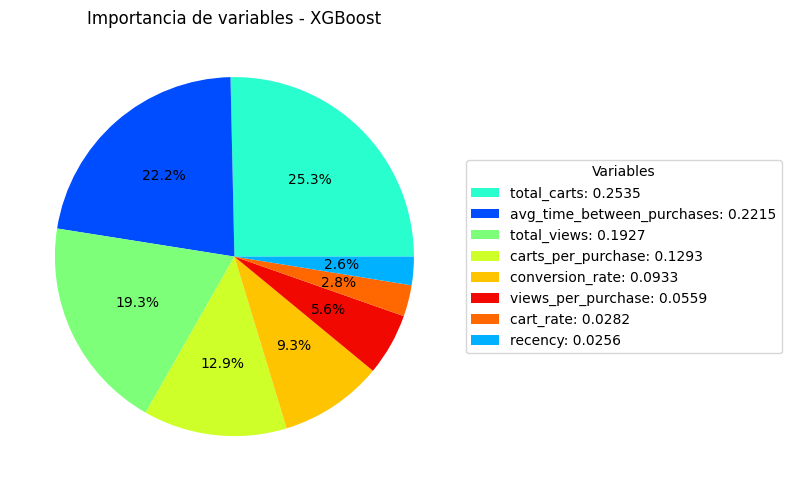


=== IMPORTANCIA DE VARIABLES RANDOM FOREST ===

total_carts                   0.253468
avg_time_between_purchases    0.221515
total_views                   0.192685
carts_per_purchase            0.129308
conversion_rate               0.093303
views_per_purchase            0.055924
cart_rate                     0.028209
recency                       0.025588
dtype: float32


In [21]:
# ============================================
# 9. IMPORTANCIA DE CARACTERÍSTICAS
# ============================================
# Ordenar importancia
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    importance.values,
    labels=None,  
    colors=[feature_color[f] for f in importance.index],
    autopct="%1.1f%%"
)

legend_labels = [
    f"{feat}: {val:.4f}"
    for feat, val in zip(importance.index, importance.values)
]

plt.legend(
    wedges,
    legend_labels,
    title="Variables",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Importancia de variables - XGBoost")
plt.tight_layout()
plt.show()
print("\n=== IMPORTANCIA DE VARIABLES RANDOM FOREST ===\n")
print(importance)

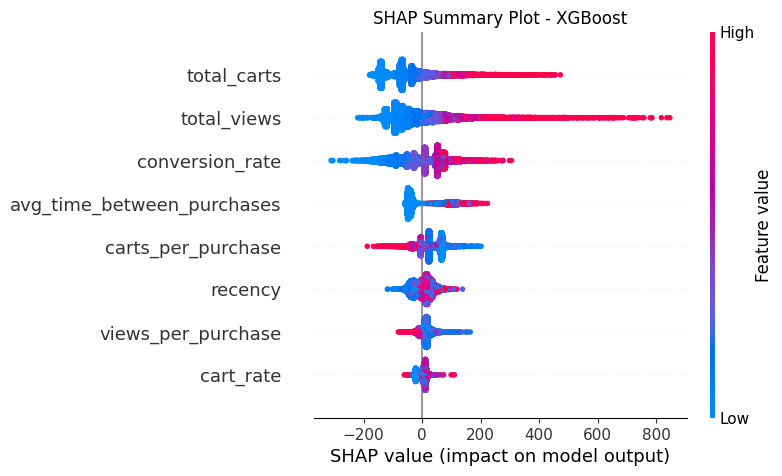

In [32]:
# crear explainer
explainer = shap.TreeExplainer(
    xgb_model,
    approximate=True
)

# calcular shap values
X_shap = X_test[:10000]
shap_values = explainer.shap_values(X_shap)

# ============================================
# SUMMARY PLOT
# ============================================

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns,
    show=False
)
plt.title("SHAP Summary Plot - XGBoost")
plt.show()

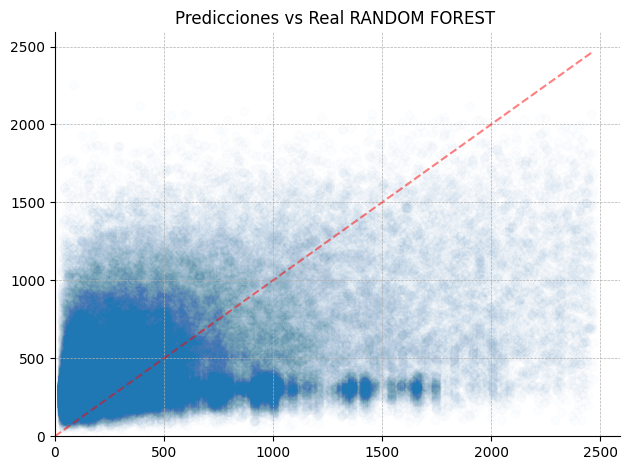

In [23]:
# Encontrar el valor máximo para establecer límites
max_valor_real = max(y_test.max(), y_test.max())
max_valor_pred = max(y_pred.max(), y_pred.max())
limite_max = max(max_valor_real, max_valor_pred)

plt.title("Predicciones vs Real RANDOM FOREST ")
plt.scatter(y_test, y_pred, alpha=0.01)
plt.plot([0, limite_max], [0, limite_max], 'r--', alpha=0.5)  # Línea de referencia
plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

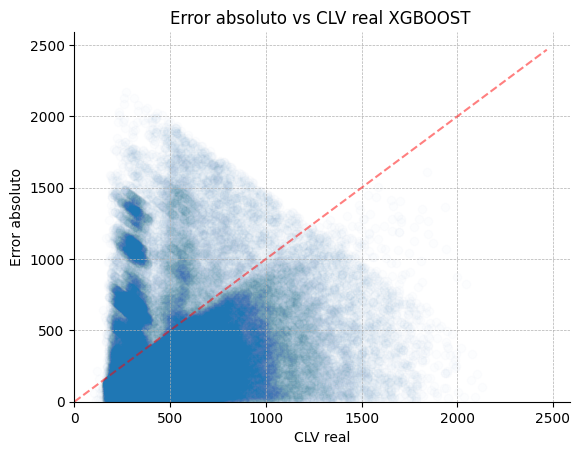

In [24]:
abs_errors = abs( y_test - y_pred_xgb)

plt.figure()
plt.scatter(y_pred_xgb, abs_errors, alpha=0.01)
plt.title("Error absoluto vs CLV real XGBOOST ")
plt.xlabel("CLV real")
plt.ylabel("Error absoluto")
plt.plot([0, limite_max], [0, limite_max], 'r--', alpha=0.5)  # Línea de referencia
plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

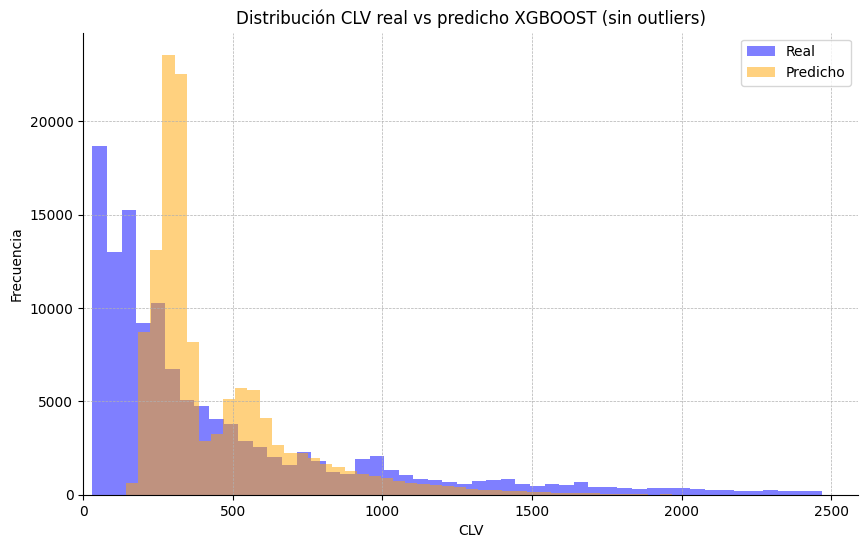

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(y_test, bins=50, alpha=0.5, label="Real", color='blue')
plt.hist(y_pred_xgb, bins=50, alpha=0.5, label="Predicho", color='orange')
plt.title("Distribución CLV real vs predicho XGBOOST (sin outliers)")
plt.xlabel("CLV")
plt.ylabel("Frecuencia")
plt.legend()
plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [26]:
# Guardar modelo entrenado en un archivo pickle
with open('XGB_model.pkl','wb') as f:
    pickle.dump(xgb_model,f)

## Segmentación de Clientes

Clustering con K-Means

In [27]:
# ============================================
# 10. SEGMENTACIÓN DE CLIENTES
# ============================================
# Clustering K-Means con 4 segmentos
kmeans = KMeans(n_clusters=4, random_state=123)
customer_df_clean["cluster"] = kmeans.fit_predict(X_scaled)

Análisis de segmentos

In [28]:
# ============================================
# 11. RESUMEN POR CLUSTER
# ============================================
# Estadísticas de características por cluster
cluster_summary = customer_df_clean.groupby("cluster")[features + ["CLV"]].mean()

print("\n=== PROMEDIOS POR SEGMENTO ===\n")
print(cluster_summary)


=== PROMEDIOS POR SEGMENTO ===

           recency  total_views  total_carts  conversion_rate  cart_rate  \
cluster                                                                    
0        42.585568     6.662370     0.826802         0.234380   0.125038   
1        13.680484     4.878135     2.413608         0.317387   0.427416   
2        16.505167   119.405666    55.246256         0.089105   1.086002   
3        16.587117    26.593651     5.845308         0.105761   0.236800   

         views_per_purchase  carts_per_purchase  avg_time_between_purchases  \
cluster                                                                       
0                  2.641862            0.328075                    0.230772   
1                  1.707971            0.861868                    1.009797   
2                 14.654678            8.132536                    1.609255   
3                  7.386128            1.561274                    2.495413   

                 CLV  
cluster     

In [29]:
# ============================================
# 12. DISTRIBUCIÓN DE CLIENTES POR CLUSTER
# ============================================
print("\n=== CONTEO DE CLIENTES POR SEGMENTO ===\n")
print(customer_df_clean["cluster"].value_counts())


=== CONTEO DE CLIENTES POR SEGMENTO ===

cluster
1    238223
0    224044
3    156427
2      8613
Name: count, dtype: int64


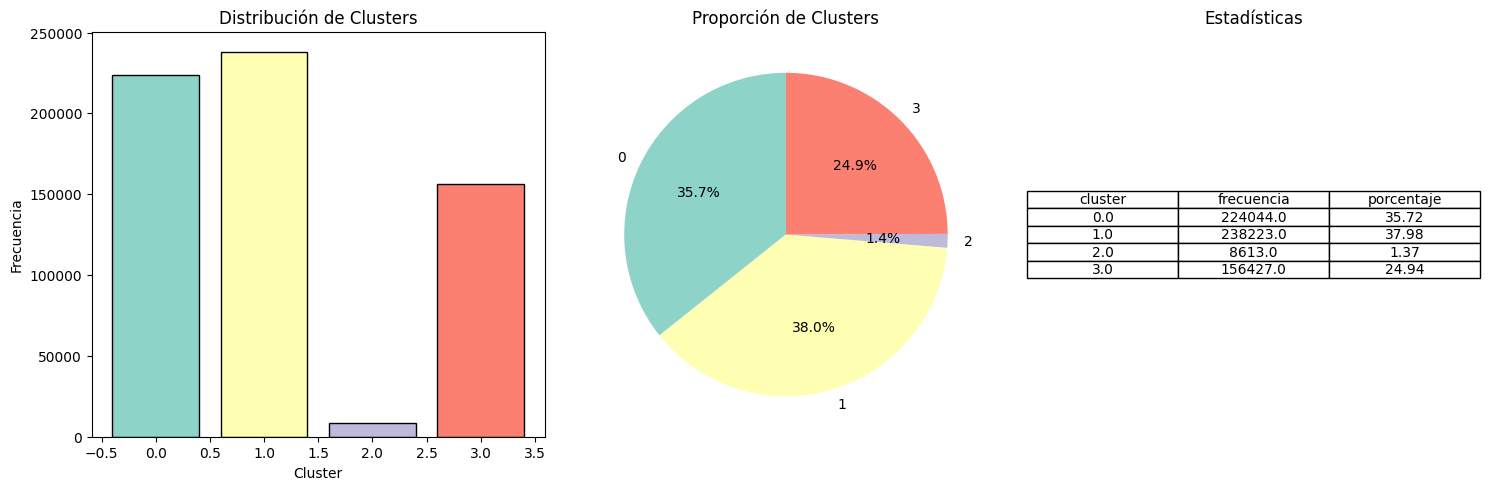

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cluster_counts = customer_df_clean["cluster"].value_counts().sort_index()

# Gráfico de barras
colors = plt.cm.Set3(range(len(cluster_counts)))
axes[0].bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')
axes[0].set_title("Distribución de Clusters", fontsize=12)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Frecuencia")

# Gráfico circular
axes[1].pie(cluster_counts.values, labels=cluster_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title("Proporción de Clusters", fontsize=12)

# Tabla de estadísticas
stats = customer_df_clean.groupby('cluster').size().reset_index(name='frecuencia')
stats['porcentaje'] = (stats['frecuencia'] / len(customer_df_clean) * 100).round(2)
axes[2].axis('tight')
axes[2].axis('off')
axes[2].table(cellText=stats.values, colLabels=stats.columns,
              cellLoc='center', loc='center')
axes[2].set_title("Estadísticas", fontsize=12)

plt.tight_layout()
plt.show()